In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models

In [2]:
# Fungsi BMR (Mifflin-St Jeor)
def calc_bmr(age, weight, height, gender):
    if gender == "male":
        return (10 * weight) + (6.25 * height) - (5 * age) + 5
    else:
        return (10 * weight) + (6.25 * height) - (5 * age) - 161

# Fungsi BMI
def calc_bmi(weight, height):
    return weight / ((height/100) ** 2)

# Fungsi TDEE dari langkah
def calc_tdee(bmr, steps):
    if steps < 5000:
        factor = 1.2
    elif steps < 7500:
        factor = 1.375
    elif steps < 10000:
        factor = 1.55
    elif steps < 12500:
        factor = 1.725
    else:
        factor = 1.9
    return bmr * factor

# Generate dataset sintetis
np.random.seed(42)
data = []

for i in range(10000):
    gender = np.random.choice(["male", "female"])

    # Distribusi fitur mendekati NHANES
    age = int(np.clip(np.random.normal(35 if gender=="male" else 34, 10), 18, 60))
    height = int(np.clip(np.random.normal(170 if gender=="male" else 160, 7), 150, 190))
    weight = int(np.clip(np.random.normal(72 if gender=="male" else 62, 12), 45, 100))
    steps = int(np.clip(np.random.normal(7500, 2500), 2000, 15000))

    bmr = calc_bmr(age, weight, height, gender)
    bmi = calc_bmi(weight, height)
    tdee = calc_tdee(bmr, steps)

    data.append([age, gender, height, weight, steps, bmr, bmi, tdee])

df = pd.DataFrame(data, columns=[
    "age", "gender", "height_cm", "weight_kg", "steps_per_day",
    "BMR", "BMI", "TDEE"
])

# Tentukan cutoff metabolisme berdasarkan persentil TDEE
slow_cutoff = np.percentile(df['TDEE'], 33)
fast_cutoff = np.percentile(df['TDEE'], 66)

def metabolism_label(tdee):
    if tdee < slow_cutoff:
        return "slow"
    elif tdee <= fast_cutoff:
        return "medium"
    else:
        return "fast"

df['metabolism_label'] = df['TDEE'].apply(metabolism_label)

print(df)
df.to_csv("metabolism_dataset_realistic.csv", index=False)


      age  gender  height_cm  weight_kg  steps_per_day      BMR        BMI  \
0      29    male        173         77          10921  1711.25  25.727555   
1      36  female        167         55           6187  1252.75  19.721037   
2      49    male        180         45           9008  1335.00  13.888889   
3      24  female        150         79           6935  1446.50  35.111111   
4      36    male        169         85           7238  1731.25  29.760863   
...   ...     ...        ...        ...            ...      ...        ...   
9995   34    male        168         81           6471  1695.00  28.698980   
9996   49  female        168         65           9617  1294.00  23.030045   
9997   18    male        174         63           6915  1632.50  20.808561   
9998   37  female        156         54           8081  1169.00  22.189349   
9999   18  female        158         66           5075  1396.50  26.438071   

            TDEE metabolism_label  
0     2951.90625           

In [3]:
# Load dataset
df = pd.read_csv("metabolism_dataset_realistic.csv")

features = ['age', 'gender', 'height_cm', 'weight_kg', 'steps_per_day', 'BMR', 'BMI']
X = df[features].copy()
y = df['metabolism_label']
# Preprocessing

X = pd.get_dummies(X, columns=['gender'], prefix='gender')
# 2. Encode label y -> numerik (0: slow, 1: medium, 2: fast), lalu one-hot untuk multi-class
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded, num_classes=3)  # One-hot: [[1,0,0], [0,1,0], [0,0,1]]
# 3. Normalisasi fitur numerik (StandardScaler untuk mean=0, std=1)
numerical_features = ['age', 'height_cm', 'weight_kg', 'steps_per_day', 'BMR', 'BMI']
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])
# 4. Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded)
print(f"Shape X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Distribusi label: {np.unique(y_encoded, return_counts=True)}")  # Cek balance kelas

Shape X_train: (8000, 8), y_train: (8000, 3)
Distribusi label: (array([0, 1, 2]), array([3399, 3301, 3300]))


In [4]:
# Bangun model Sequential
model = Sequential([
    # Input layer + Hidden layer 1
    Dense(128, input_dim=X_train.shape[1], activation='relu'),  # 128 neuron
    Dropout(0.3),  # Dropout untuk regularization

    # Hidden layer 2
    Dense(64, activation='relu'),  # 64 neuron
    Dropout(0.2),

    # Hidden layer 3 (opsional, untuk kompleksitas lebih)
    Dense(32, activation='relu'),

    # Output layer
    Dense(3, activation='softmax')  # 3 kelas, softmax untuk probabilitas
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary model
model.summary()

# Callback untuk early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,  # 20% dari train untuk validasi
    callbacks=[early_stopping],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,587 (45.26 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6893 - loss: 0.6762 - val_accuracy: 0.8875 - val_loss: 0.2565
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8680 - loss: 0.3051 - val_accuracy: 0.8919 - val_loss: 0.2411
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8689 - loss: 0.2857 - val_accuracy: 0.8819 - val_loss: 0.2466
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8813 - loss: 0.2744 - val_accuracy: 0.8938 - val_loss: 0.2381
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8743 - loss: 0.2672 - val_accuracy: 0.8969 - val_loss: 0.2395
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8706 - loss: 0.2767 - val_accuracy: 0.8988 - val_loss: 0.2297
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8869 - loss: 0.2443 - val_accuracy: 0.9006 - val_loss: 0.2308
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8874 - loss: 0.2438 - val_accu

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Classification Report:
              precision    recall  f1-score   support

        fast       0.98      0.97      0.98       680
      medium       0.95      0.97      0.96       660
        slow       0.99      0.98      0.98       660

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



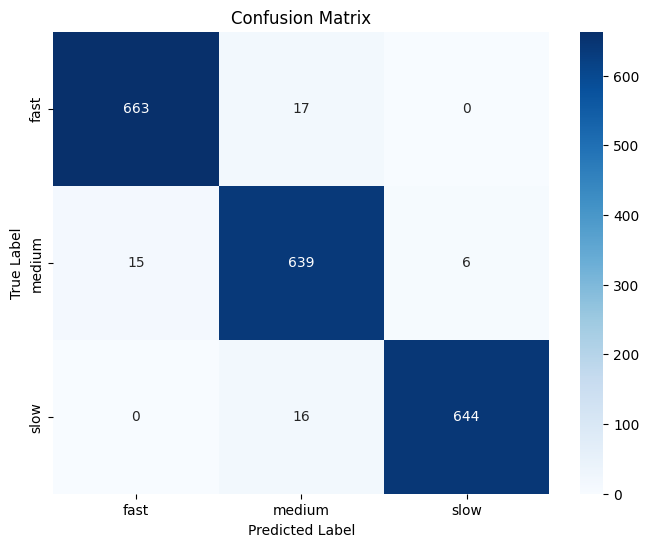

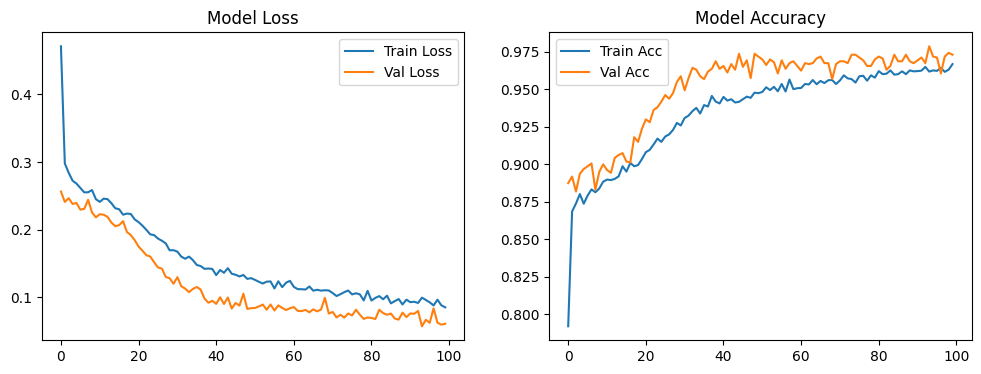

Test Accuracy: 0.9730


In [5]:
# Prediksi pada test set
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_test_argmax = np.argmax(y_test, axis=1)

# Metrik
print("Classification Report:")
print(classification_report(y_test_argmax, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test_argmax, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Akurasi test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")


In [6]:
new_data_slow = pd.DataFrame({
    'age': [50], 'height_cm': [160], 'weight_kg': [80],
    'steps_per_day': [3000], 'BMR': [1300], 'BMI': [31.25],
    'gender_male': [0], 'gender_female': [1]
})
new_data_slow[numerical_features] = scaler.transform(new_data_slow[numerical_features])
pred_proba_slow = model.predict(new_data_slow)
pred_class_slow = label_encoder.inverse_transform(np.argmax(pred_proba_slow, axis=1))
print(f"Test 1: {pred_class_slow[0]} (Prob: {np.max(pred_proba_slow):.4f})")

new_data_medium = pd.DataFrame({
    'age': [21], 'height_cm': [165], 'weight_kg': [65],
    'steps_per_day': [10000], 'BMR': [2200], 'BMI': [23.88],
    'gender_male': [1], 'gender_female': [0]
})
new_data_medium[numerical_features] = scaler.transform(new_data_medium[numerical_features])
pred_proba_medium = model.predict(new_data_medium)
pred_class_medium = label_encoder.inverse_transform(np.argmax(pred_proba_medium, axis=1))
print(f"Test 2: {pred_class_medium[0]} (Prob: {np.max(pred_proba_medium):.4f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
Test 1: slow (Prob: 1.0000)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Test 2: fast (Prob: 1.0000)


In [7]:
items_data = pd.DataFrame([
    {"item_id": 1, "nama": "Latihan Kardio 20 Menit", "kategori": "olahraga", "target": "fast", "intensitas": 0.8, "durasi": 20},
    {"item_id": 2, "nama": "Yoga Pagi", "kategori": "relaksasi", "target": "medium", "intensitas": 0.3, "durasi": 30},
    {"item_id": 3, "nama": "Tidur Cukup 8 Jam", "kategori": "tidur", "target": "slow", "intensitas": 0.1, "durasi": 480},
    {"item_id": 4, "nama": "Diet Tinggi Protein", "kategori": "nutrisi", "target": "fast", "intensitas": 0.7, "durasi": 0},
    {"item_id": 5, "nama": "Meditasi 15 Menit", "kategori": "relaksasi", "target": "slow", "intensitas": 0.2, "durasi": 15},
    {"item_id": 6, "nama": "Minum Air 2 Liter Sehari", "kategori": "kebiasaan", "target": "medium", "intensitas": 0.4, "durasi": 0},
    {"item_id": 7, "nama": "Jalan Santai 30 Menit", "kategori": "olahraga", "target": "medium", "intensitas": 0.5, "durasi": 30},
    {"item_id": 8, "nama": "Makan Sayur Setiap Hari", "kategori": "nutrisi", "target": "slow", "intensitas": 0.3, "durasi": 0},
    {"item_id": 9, "nama": "HIIT(High Intensity Interval Training) 10 Menit", "kategori": "olahraga", "target": "fast", "intensitas": 0.9, "durasi": 10},
    {"item_id": 10, "nama": "Tidur Sebelum Jam 10", "kategori": "tidur", "target": "medium", "intensitas": 0.2, "durasi": 0},
])

kategori_encoder = LabelEncoder()
items_data["kategori_encoded"] = kategori_encoder.fit_transform(items_data["kategori"])
target_encoder = LabelEncoder()
items_data["target_encoded"] = target_encoder.fit_transform(items_data["target"])
item_scaler = StandardScaler()
items_data[["intensitas_scaled", "durasi_scaled"]] = item_scaler.fit_transform(
    items_data[["intensitas", "durasi"]])

In [8]:
df_processed = df.copy()
df_processed = pd.get_dummies(df_processed, columns=["gender"], prefix="gender")

if "gender_male" not in df_processed.columns:
    df_processed["gender_male"] = 0
if "gender_female" not in df_processed.columns:
    df_processed["gender_female"] = 0

print(f"Columns: {df_processed.columns.tolist()}")

Columns: ['age', 'height_cm', 'weight_kg', 'steps_per_day', 'BMR', 'BMI', 'TDEE', 'metabolism_label', 'gender_female', 'gender_male']


In [9]:
user_input_features = ["age", "height_cm", "weight_kg", "steps_per_day", "BMR", "BMI", "gender_male", "gender_female"]
n_user_features = len(user_input_features)

user_input = layers.Input(shape=(n_user_features,), name="user_input")
user_dense1 = layers.Dense(128, activation="relu")(user_input)
user_dropout1 = layers.Dropout(0.3)(user_dense1)
user_dense2 = layers.Dense(64, activation="relu")(user_dropout1)
user_dropout2 = layers.Dropout(0.2)(user_dense2)
user_embedding = layers.Dense(32, activation="relu", name="user_embedding")(user_dropout2)

user_tower = models.Model(user_input, user_embedding, name="user_tower")

In [10]:
item_target_input = layers.Input(shape=(1,), name="item_target")
item_kategori_input = layers.Input(shape=(1,), name="item_kategori")
item_numeric_input = layers.Input(shape=(2,), name="item_numeric")

target_embedding = layers.Embedding(input_dim=3, output_dim=16)(item_target_input)
target_flat = layers.Flatten()(target_embedding)

kategori_embedding = layers.Embedding(input_dim=len(kategori_encoder.classes_), output_dim=8)(item_kategori_input)
kategori_flat = layers.Flatten()(kategori_embedding)

item_concat = layers.Concatenate()([target_flat, kategori_flat, item_numeric_input])
item_dense1 = layers.Dense(64, activation="relu")(item_concat)
item_dense2 = layers.Dense(32, activation="relu")(item_dense1)
item_embedding = layers.Dense(32, activation="relu", name="item_embedding")(item_dense2)

item_tower = models.Model(
    [item_target_input, item_kategori_input, item_numeric_input],
    item_embedding,
    name="item_tower"
)
similarity = layers.Dot(axes=1, normalize=True)([user_embedding, item_embedding])
output = layers.Dense(1, activation="sigmoid")(similarity)

two_tower_model = models.Model(
    inputs=[user_input, item_target_input, item_kategori_input, item_numeric_input],
    outputs=output,
    name="two_tower_recommender"
)

two_tower_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model Architecture:")
two_tower_model.summary()

Model Architecture:


Model: "two_tower_recommender"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ item_target         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_kategori       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_input          │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 16)     │         48 │ item_target[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 8)      │         40 │ item_kategori[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      1,152 │ user_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_numeric        │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 26)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ item_numeric[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      1,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,080 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 32)        │      1,056 │ dense_7[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ user_embedding[0… │
│                     │                   │            │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │          2 │ dot[0][0]         │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 16,442 (64.23 KB)

 Trainable params: 16,442 (64.23 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def generate_training_pairs(df, items_df, n_samples=5000):
    X_user_list = []
    X_item_target_list = []
    X_item_kategori_list = []
    X_item_numeric_list = []
    y_list = []

    for _ in range(n_samples):
        user_idx = np.random.randint(0, len(df))
        user = df.iloc[user_idx]
        user_metabolism = user["metabolism_label"]

        matching_items = items_df[items_df["target"] == user_metabolism]
        if len(matching_items) > 0:
            item = matching_items.sample(1).iloc[0]

            user_features = user[user_input_features].values.astype(np.float32)
            X_user_list.append(user_features)
            X_item_target_list.append(int(item["target_encoded"]))
            X_item_kategori_list.append(int(item["kategori_encoded"]))
            X_item_numeric_list.append([float(item["intensitas_scaled"]), float(item["durasi_scaled"])])
            y_list.append(1.0)

        non_matching_items = items_df[items_df["target"] != user_metabolism]
        if len(non_matching_items) > 0:
            item = non_matching_items.sample(1).iloc[0]

            user_features = user[user_input_features].values.astype(np.float32)
            X_user_list.append(user_features)
            X_item_target_list.append(int(item["target_encoded"]))
            X_item_kategori_list.append(int(item["kategori_encoded"]))
            X_item_numeric_list.append([float(item["intensitas_scaled"]), float(item["durasi_scaled"])])
            y_list.append(0.0)

    return (
        np.array(X_user_list, dtype=np.float32),
        np.array(X_item_target_list, dtype=np.int32).reshape(-1, 1),
        np.array(X_item_kategori_list, dtype=np.int32).reshape(-1, 1),
        np.array(X_item_numeric_list, dtype=np.float32),
        np.array(y_list, dtype=np.float32)
    )

In [12]:
X_user_train, X_target_train, X_kategori_train, X_numeric_train, y_train = generate_training_pairs(df_processed, items_data)
X_user_train = np.array(X_user_train, dtype=np.float32)
X_target_train = np.array(X_target_train, dtype=np.int32)
X_kategori_train = np.array(X_kategori_train, dtype=np.int32)
X_numeric_train = np.array(X_numeric_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)

numerical_features_for_scaling = ["age", "height_cm", "weight_kg", "steps_per_day", "BMR", "BMI"]
X_user_train_scaled = X_user_train.copy()
X_user_train_scaled[:, :6] = scaler.transform(
    pd.DataFrame(X_user_train[:, :6], columns=numerical_features_for_scaling)
).astype(np.float32)

print(f"X_user: {X_user_train_scaled.shape} (dtype: {X_user_train_scaled.dtype})")
print(f"X_target: {X_target_train.shape} (dtype: {X_target_train.dtype})")
print(f"X_kategori: {X_kategori_train.shape} (dtype: {X_kategori_train.dtype})")
print(f"X_numeric: {X_numeric_train.shape} (dtype: {X_numeric_train.dtype})")
print(f"y_train: {y_train.shape} (dtype: {y_train.dtype})")

X_user: (10000, 8) (dtype: float32)
X_target: (10000, 1) (dtype: int32)
X_kategori: (10000, 1) (dtype: int32)
X_numeric: (10000, 2) (dtype: float32)
y_train: (10000,) (dtype: float32)


In [13]:
history = two_tower_model.fit(
    [X_user_train_scaled, X_target_train, X_kategori_train, X_numeric_train],
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

class ColdStartHandler:

    def __init__(self, items_df):
        self.items_df = items_df
        self.popularity_scores = self._calculate_popularity()

    def _calculate_popularity(self):
        popularity = {}
        for idx, item in self.items_df.iterrows():
            score = 1.0 - abs(item["intensitas"] - 0.5)
            popularity[item["item_id"]] = score
        return popularity

    def get_cold_start_recommendations(self, top_k=3):
        sorted_items = sorted(
            self.popularity_scores.items(),
            key=lambda x: x[1],
            reverse=True
        )
        top_item_ids = [item_id for item_id, _ in sorted_items[:top_k]]
        return self.items_df[self.items_df["item_id"].isin(top_item_ids)]

cold_start_handler = ColdStartHandler(items_data)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5807 - loss: 0.6602 - val_accuracy: 0.8550 - val_loss: 0.5518
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8561 - loss: 0.5489 - val_accuracy: 0.9310 - val_loss: 0.4936
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9013 - loss: 0.5051 - val_accuracy: 0.9325 - val_loss: 0.4668
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9173 - loss: 0.4709 - val_accuracy: 0.9360 - val_loss: 0.4434
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9146 - loss: 0.4533 - val_accuracy: 0.9345 - val_loss: 0.4277
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9178 - loss: 0.4350 - val_accuracy: 0.9355 - val_loss: 0.4073
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9196 - loss: 0.4217 - val_accuracy: 0.9380 - val_loss: 0.3921
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9240 - loss: 0.4014 - val_accuracy: 0

In [14]:
def get_recommendations(user_profile, top_k=3, use_metabolism_model=True):

    print("\n")
    print("SISTEM REKOMENDASI METABOLISME")
    if user_profile is None or len(user_profile) == 0:
        recommendations = cold_start_handler.get_cold_start_recommendations(top_k)
        print("Rekomendasi untuk pengguna (Populer untuk Pemula):")
        for idx, row in recommendations.iterrows():
            print(f"{row["nama"]}")
            print(f"Kategori: {row["kategori"]} | Intensitas: {row["intensitas"]:.1f}/1.0")
            print()
        return recommendations

    required_features = ["age", "height_cm", "weight_kg", "steps_per_day", "BMR", "BMI", "gender"]
    missing_features = [f for f in required_features if f not in user_profile]
    if missing_features:
        print(f"\nWARNING: Missing features: {missing_features}")
        return get_recommendations(None, top_k, use_metabolism_model)
    metabolism_pred = "medium"
    confidence = 0.5

    if use_metabolism_model:
        try:
            df_input = pd.DataFrame([user_profile])
            df_input = pd.get_dummies(df_input, columns=["gender"], prefix="gender")
            if "gender_male" not in df_input.columns:
                df_input["gender_male"] = 0
            if "gender_female" not in df_input.columns:
                df_input["gender_female"] = 0
            feature_order = ["age", "height_cm", "weight_kg", "steps_per_day", "BMR", "BMI", "gender_male", "gender_female"]
            df_input = df_input[feature_order]
            X_scaled = df_input.copy()
            X_scaled[numerical_features_for_scaling] = scaler.transform(df_input[numerical_features_for_scaling])
            X_scaled = X_scaled.values.astype(np.float32)
            y_pred = model.predict(X_scaled, verbose=0)
            metabolism_pred = label_encoder.inverse_transform(np.argmax(y_pred, axis=1))[0]
            confidence = np.max(y_pred)

        except Exception as e:
            print(f"Error in metabolism prediction: {e}")
            print("Using default metabolism level: medium\n")

    print(f"\nANALISIS PROFIL PENGGUNA")
    print("\n")
    print(f"Usia: {user_profile["age"]} tahun")
    print(f"Gender: {user_profile["gender"]}")
    print(f"Tinggi: {user_profile["height_cm"]} cm")
    print(f"Berat: {user_profile["weight_kg"]} kg")
    print(f"Aktivitas: {user_profile["steps_per_day"]} langkah/hari")
    print(f"BMI: {user_profile["BMI"]:.1f}")
    print(f"BMR: {user_profile["BMR"]:.0f} kkal/hari")
    print(f"Metabolisme: {metabolism_pred.upper()}")
    print(f"Confidence: {confidence:.1%}")

    df_for_tower = pd.DataFrame([user_profile])
    df_for_tower = pd.get_dummies(df_for_tower, columns=["gender"], prefix="gender")
    if "gender_male" not in df_for_tower.columns:
        df_for_tower["gender_male"] = 0
    if "gender_female" not in df_for_tower.columns:
        df_for_tower["gender_female"] = 0
    df_for_tower = df_for_tower[user_input_features]
    X_user = df_for_tower.copy()
    X_user[numerical_features_for_scaling] = scaler.transform(df_for_tower[numerical_features_for_scaling])
    X_user = X_user.values.astype(np.float32)

    scores = []
    for idx, item in items_data.iterrows():
        X_target = np.array([[item["target_encoded"]]], dtype=np.int32)
        X_kategori = np.array([[item["kategori_encoded"]]], dtype=np.int32)
        X_numeric = np.array([[item["intensitas_scaled"], item["durasi_scaled"]]], dtype=np.float32)

        score = two_tower_model.predict(
            [X_user, X_target, X_kategori, X_numeric],
            verbose=0
        )[0][0]
        scores.append(float(score))

    items_data["recommendation_score"] = scores
    recommendations = items_data.sort_values("recommendation_score", ascending=False).head(top_k)

    print(f"\nTOP {top_k} REKOMENDASI UNTUK PENGGUNA:")
    print("\n")
    for idx, row in recommendations.iterrows():
        print(f"{row["nama"]}")
        print(f"Kategori: {row["kategori"]} | Target: {row["target"]}")
        print(f"Match Score: {row["recommendation_score"]:.1%}")
        print()
    return recommendations

In [15]:
print("[TEST 1] Cold Start User (No Profile)")
get_recommendations(None, top_k=3)

[TEST 1] Cold Start User (No Profile)


SISTEM REKOMENDASI METABOLISME
Rekomendasi untuk pengguna (Populer untuk Pemula):
Yoga Pagi
Kategori: relaksasi | Intensitas: 0.3/1.0

Minum Air 2 Liter Sehari
Kategori: kebiasaan | Intensitas: 0.4/1.0

Jalan Santai 30 Menit
Kategori: olahraga | Intensitas: 0.5/1.0



,item_id,nama,kategori,target,intensitas,durasi,kategori_encoded,target_encoded,intensitas_scaled,durasi_scaled
1,2,Yoga Pagi,relaksasi,medium,0.3,30,3,1,-0.535303,-0.202182
5,6,Minum Air 2 Liter Sehari,kebiasaan,medium,0.4,0,0,1,-0.152944,-0.415006
6,7,Jalan Santai 30 Menit,olahraga,medium,0.5,30,2,1,0.229416,-0.202182


In [16]:
print("[TEST 2] User dengan Metabolisme Slow")
user_slow = {
    "age": 50,
    "gender": "female",
    "height_cm": 160,
    "weight_kg": 80,
    "steps_per_day": 3000,
    "BMR": 1300,
    "BMI": 31.25
}
get_recommendations(user_slow, top_k=3)

[TEST 2] User dengan Metabolisme Slow


SISTEM REKOMENDASI METABOLISME

ANALISIS PROFIL PENGGUNA


Usia: 50 tahun
Gender: female
Tinggi: 160 cm
Berat: 80 kg
Aktivitas: 3000 langkah/hari
BMI: 31.2
BMR: 1300 kkal/hari
Metabolisme: SLOW
Confidence: 100.0%

TOP 3 REKOMENDASI UNTUK PENGGUNA:


Meditasi 15 Menit
Kategori: relaksasi | Target: slow
Match Score: 95.3%

Makan Sayur Setiap Hari
Kategori: nutrisi | Target: slow
Match Score: 95.3%

Tidur Cukup 8 Jam
Kategori: tidur | Target: slow
Match Score: 95.2%



,item_id,nama,kategori,target,intensitas,durasi,kategori_encoded,target_encoded,intensitas_scaled,durasi_scaled,recommendation_score
4,5,Meditasi 15 Menit,relaksasi,slow,0.2,15,3,2,-0.917663,-0.308594,0.952755
7,8,Makan Sayur Setiap Hari,nutrisi,slow,0.3,0,1,2,-0.535303,-0.415006,0.952695
2,3,Tidur Cukup 8 Jam,tidur,slow,0.1,480,4,2,-1.300022,2.990170,0.952487


In [17]:
print("[TEST 3] User dengan Metabolisme Medium")
user_medium = {
    "age": 30,
    "gender": "male",
    "height_cm": 170,
    "weight_kg": 85,
    "steps_per_day": 8000,
    "BMR": 1300,
    "BMI": 26.25
}
get_recommendations(user_medium, top_k=3)

[TEST 3] User dengan Metabolisme Medium


SISTEM REKOMENDASI METABOLISME

ANALISIS PROFIL PENGGUNA


Usia: 30 tahun
Gender: male
Tinggi: 170 cm
Berat: 85 kg
Aktivitas: 8000 langkah/hari
BMI: 26.2
BMR: 1300 kkal/hari
Metabolisme: MEDIUM
Confidence: 90.4%

TOP 3 REKOMENDASI UNTUK PENGGUNA:


Jalan Santai 30 Menit
Kategori: olahraga | Target: medium
Match Score: 79.3%

Yoga Pagi
Kategori: relaksasi | Target: medium
Match Score: 79.3%

Minum Air 2 Liter Sehari
Kategori: kebiasaan | Target: medium
Match Score: 79.3%



,item_id,nama,kategori,target,intensitas,durasi,kategori_encoded,target_encoded,intensitas_scaled,durasi_scaled,recommendation_score
6,7,Jalan Santai 30 Menit,olahraga,medium,0.5,30,2,1,0.229416,-0.202182,0.793357
1,2,Yoga Pagi,relaksasi,medium,0.3,30,3,1,-0.535303,-0.202182,0.792718
5,6,Minum Air 2 Liter Sehari,kebiasaan,medium,0.4,0,0,1,-0.152944,-0.415006,0.792573


In [18]:
print("[TEST 4] User dengan Metabolisme Fast")
user_fast = {
    "age": 25,
    "gender": "male",
    "height_cm": 175,
    "weight_kg": 70,
    "steps_per_day": 12000,
    "BMR": 1700,
    "BMI": 22.86
}
get_recommendations(user_fast, top_k=3)

[TEST 4] User dengan Metabolisme Fast


SISTEM REKOMENDASI METABOLISME

ANALISIS PROFIL PENGGUNA


Usia: 25 tahun
Gender: male
Tinggi: 175 cm
Berat: 70 kg
Aktivitas: 12000 langkah/hari
BMI: 22.9
BMR: 1700 kkal/hari
Metabolisme: FAST
Confidence: 100.0%

TOP 3 REKOMENDASI UNTUK PENGGUNA:


Diet Tinggi Protein
Kategori: nutrisi | Target: fast
Match Score: 95.3%

HIIT(High Intensity Interval Training) 10 Menit
Kategori: olahraga | Target: fast
Match Score: 95.3%

Latihan Kardio 20 Menit
Kategori: olahraga | Target: fast
Match Score: 95.3%



,item_id,nama,kategori,target,intensitas,durasi,kategori_encoded,target_encoded,intensitas_scaled,durasi_scaled,recommendation_score
3,4,Diet Tinggi Protein,nutrisi,fast,0.7,0,1,0,0.994135,-0.415006,0.952770
8,9,HIIT(High Intensity Interval Training) 10 Menit,olahraga,fast,0.9,10,2,0,1.758854,-0.344065,0.952768
0,1,Latihan Kardio 20 Menit,olahraga,fast,0.8,20,2,0,1.376494,-0.273123,0.952766


In [19]:
print("[TEST 5] Pengguna dengan Data Tidak Lengkap")
user_incomplete = {
    "age": 30,
    "height_cm": 170
}
get_recommendations(user_incomplete, top_k=3)

[TEST 5] Pengguna dengan Data Tidak Lengkap


SISTEM REKOMENDASI METABOLISME



SISTEM REKOMENDASI METABOLISME
Rekomendasi untuk pengguna (Populer untuk Pemula):
Yoga Pagi
Kategori: relaksasi | Intensitas: 0.3/1.0

Minum Air 2 Liter Sehari
Kategori: kebiasaan | Intensitas: 0.4/1.0

Jalan Santai 30 Menit
Kategori: olahraga | Intensitas: 0.5/1.0



,item_id,nama,kategori,target,intensitas,durasi,kategori_encoded,target_encoded,intensitas_scaled,durasi_scaled,recommendation_score
1,2,Yoga Pagi,relaksasi,medium,0.3,30,3,1,-0.535303,-0.202182,0.060131
5,6,Minum Air 2 Liter Sehari,kebiasaan,medium,0.4,0,0,1,-0.152944,-0.415006,0.060131
6,7,Jalan Santai 30 Menit,olahraga,medium,0.5,30,2,1,0.229416,-0.202182,0.060131
